***Assignments 03:-  Use Naïve Bayes or TF-IDF + SVM to classify emails as 
    phishing or legitimate based on word patterns<br>***

**Name:-Vaishnavi Sharad Gavali <br>**
**Div:-TY-AIDS-A (C) <br>**
**Roll No:-EN24107044**

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [14]:
df = pd.read_csv("Phishing_Email.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (18650, 3)


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [15]:
print(df.columns)

Index(['Unnamed: 0', 'Email Text', 'Email Type'], dtype='str')


In [16]:
print(df.isnull().sum())

Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64


In [17]:
df = df.drop(columns=["Unnamed: 0"])

df.head()

,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [18]:
df = df.dropna(subset=["Email Text"])

print(df.isnull().sum())
print("Dataset shape:", df.shape)

Email Text    0
Email Type    0
dtype: int64
Dataset shape: (18634, 2)


In [19]:
print(df["Email Type"].value_counts())

Email Type
Safe Email        11322
Phishing Email     7312
Name: count, dtype: int64


In [20]:
X = df["Email Text"]
y = df["Email Type"]

print("Input:")
print(X.head())

print("\nOutput:")
print(y.head())

Input:
0    re : 6 . 1100 , disc : uniformitarianism , re ...
1    the other side of * galicismos * * galicismo *...
2    re : equistar deal tickets are you still avail...
3    \nHello I am your hot lil horny toy.\n    I am...
4    software at incredibly low prices ( 86 % lower...
Name: Email Text, dtype: str

Output:
0        Safe Email
1        Safe Email
2        Safe Email
3    Phishing Email
4    Phishing Email
Name: Email Type, dtype: str


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 14907
Testing data: 3727


In [22]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

In [23]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (14907, 5000)
Testing TF-IDF shape: (3727, 5000)


In [24]:
nb_model = MultinomialNB()

In [25]:
nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [26]:
nb_pred = nb_model.predict(X_test_tfidf)

print(nb_pred[:10])

['Safe Email' 'Safe Email' 'Safe Email' 'Safe Email' 'Safe Email'
 'Phishing Email' 'Phishing Email' 'Safe Email' 'Safe Email' 'Safe Email']


In [27]:
nb_accuracy = accuracy_score(y_test, nb_pred)

nb_precision = precision_score(
    y_test,
    nb_pred,
    pos_label="Phishing Email"
)

nb_recall = recall_score(
    y_test,
    nb_pred,
    pos_label="Phishing Email"
)

nb_f1 = f1_score(
    y_test,
    nb_pred,
    pos_label="Phishing Email"
)

print("Naive Bayes Results")
print("-------------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Naive Bayes Results
-------------------------
Accuracy : 0.9511671585725785
Precision: 0.9584527220630372
Recall   : 0.9151846785225718
F1 Score : 0.9363191042687193


In [28]:
print(classification_report(y_test, nb_pred))

                precision    recall  f1-score   support

Phishing Email       0.96      0.92      0.94      1462
    Safe Email       0.95      0.97      0.96      2265

      accuracy                           0.95      3727
     macro avg       0.95      0.94      0.95      3727
  weighted avg       0.95      0.95      0.95      3727



In [29]:
svm_model = LinearSVC()

In [30]:
svm_model.fit(X_train_tfidf, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [31]:
svm_pred = svm_model.predict(X_test_tfidf)

print(svm_pred[:10])

['Safe Email' 'Safe Email' 'Safe Email' 'Safe Email' 'Phishing Email'
 'Phishing Email' 'Phishing Email' 'Safe Email' 'Phishing Email'
 'Safe Email']


In [32]:
svm_accuracy = accuracy_score(y_test, svm_pred)

svm_precision = precision_score(
    y_test,
    svm_pred,
    pos_label="Phishing Email"
)

svm_recall = recall_score(
    y_test,
    svm_pred,
    pos_label="Phishing Email"
)

svm_f1 = f1_score(
    y_test,
    svm_pred,
    pos_label="Phishing Email"
)

print("TF-IDF + SVM Results")
print("-------------------------")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

TF-IDF + SVM Results
-------------------------
Accuracy : 0.9742420177086129
Precision: 0.9511228533685601
Recall   : 0.9849521203830369
F1 Score : 0.967741935483871


In [33]:
print(classification_report(y_test, svm_pred))

                precision    recall  f1-score   support

Phishing Email       0.95      0.98      0.97      1462
    Safe Email       0.99      0.97      0.98      2265

      accuracy                           0.97      3727
     macro avg       0.97      0.98      0.97      3727
  weighted avg       0.97      0.97      0.97      3727



In [34]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    
    "Naive Bayes": [
        nb_accuracy,
        nb_precision,
        nb_recall,
        nb_f1
    ],
    
    "TF-IDF + SVM": [
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1
    ]
})

comparison

,Metric,Naive Bayes,TF-IDF + SVM
0,Accuracy,0.951167,0.974242
1,Precision,0.958453,0.951123
2,Recall,0.915185,0.984952
3,F1 Score,0.936319,0.967742


In [35]:
print("Naive Bayes Accuracy :", round(nb_accuracy * 100, 2), "%")
print("SVM Accuracy         :", round(svm_accuracy * 100, 2), "%")

Naive Bayes Accuracy : 95.12 %
SVM Accuracy         : 97.42 %


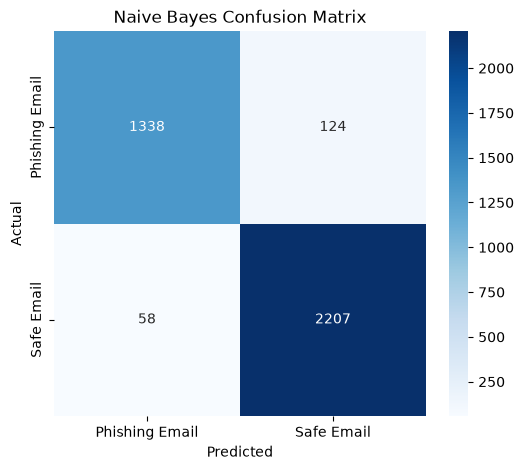

In [36]:
nb_cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Phishing Email", "Safe Email"],
    yticklabels=["Phishing Email", "Safe Email"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

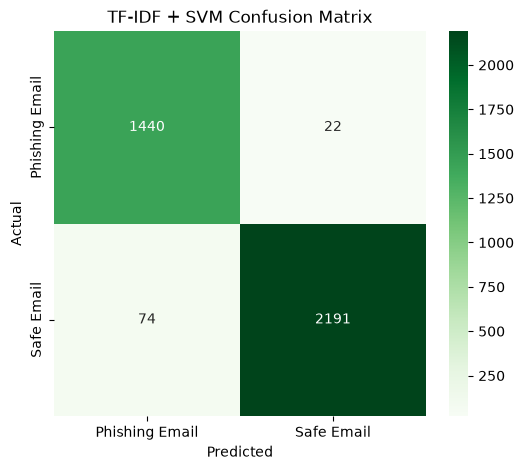

In [37]:
svm_cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Phishing Email", "Safe Email"],
    yticklabels=["Phishing Email", "Safe Email"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TF-IDF + SVM Confusion Matrix")

plt.show()

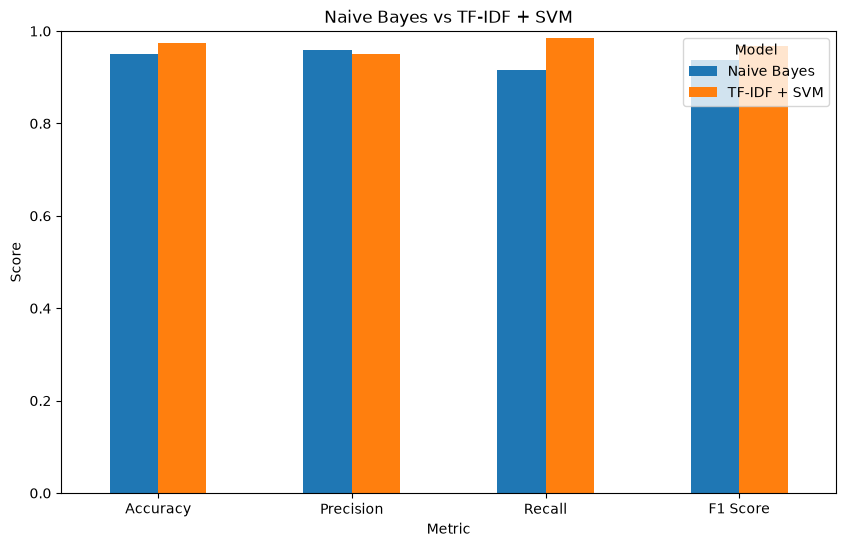

In [38]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Naive Bayes vs TF-IDF + SVM")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Model")

plt.show()

In [39]:
print("========== FINAL RESULT ==========")

print(f"Naive Bayes Accuracy : {nb_accuracy * 100:.2f}%")
print(f"SVM Accuracy         : {svm_accuracy * 100:.2f}%")

print("\nNaive Bayes F1 Score :", round(nb_f1, 4))
print("SVM F1 Score         :", round(svm_f1, 4))

========== FINAL RESULT ==========
Naive Bayes Accuracy : 95.12%
SVM Accuracy         : 97.42%

Naive Bayes F1 Score : 0.9363
SVM F1 Score         : 0.9677
